# Лабораторная работа: Линейные модели, SVM и деревья решений
**Задание:** Решение задачи регрессии на датасете HousingData.

**Выполнил:** Мироненков А.М.
**Группа:** ИУ5-66Б

### 1. Импорт библиотек и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import mean_absolute_error, r2_score

# Загрузка данных
try:
    df = pd.read_csv('HousingData.csv')
    print("Данные успешно загружены!")
except FileNotFoundError:
    print("Файл HousingData.csv не найден. Пожалуйста, убедитесь, что он в той же папке.")

df.head()

Данные успешно загружены!


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


### 2. Предобработка данных
Проверим наличие пропусков и заполним их медианными значениями.

In [2]:
print("Пропуски до обработки:")
print(df.isnull().sum().sum())

# Заполнение пропусков медианой
df = df.fillna(df.median())

print("Пропуски после обработки:", df.isnull().sum().sum())

Пропуски до обработки:
5
Пропуски после обработки: 0


### 3. Разделение выборки на обучающую и тестовую
Для SVM крайне важно масштабирование признаков, поэтому применим StandardScaler.

In [3]:
X = df.drop('medv', axis=1)
y = df['medv']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (404, 13)
Размер тестовой выборки: (102, 13)


### 4. Обучение моделей
Обучим Линейную регрессию, SVM и Дерево решений.

In [4]:
# 1. Линейная регрессия
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

# 2. SVM (SVR)
model_svm = SVR(kernel='rbf', C=10.0, epsilon=0.2)
model_svm.fit(X_train_scaled, y_train)

# 3. Дерево решений
model_dt = DecisionTreeRegressor(max_depth=4, random_state=42)
model_dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


### 5. Оценка качества и сравнение моделей
Используем MAE (Mean Absolute Error) и R2 (коэффициент детерминации).

                        MAE        R2
Linear Regression  3.211449  0.666503
SVM                2.076397  0.826305
Decision Tree      2.894622  0.730004


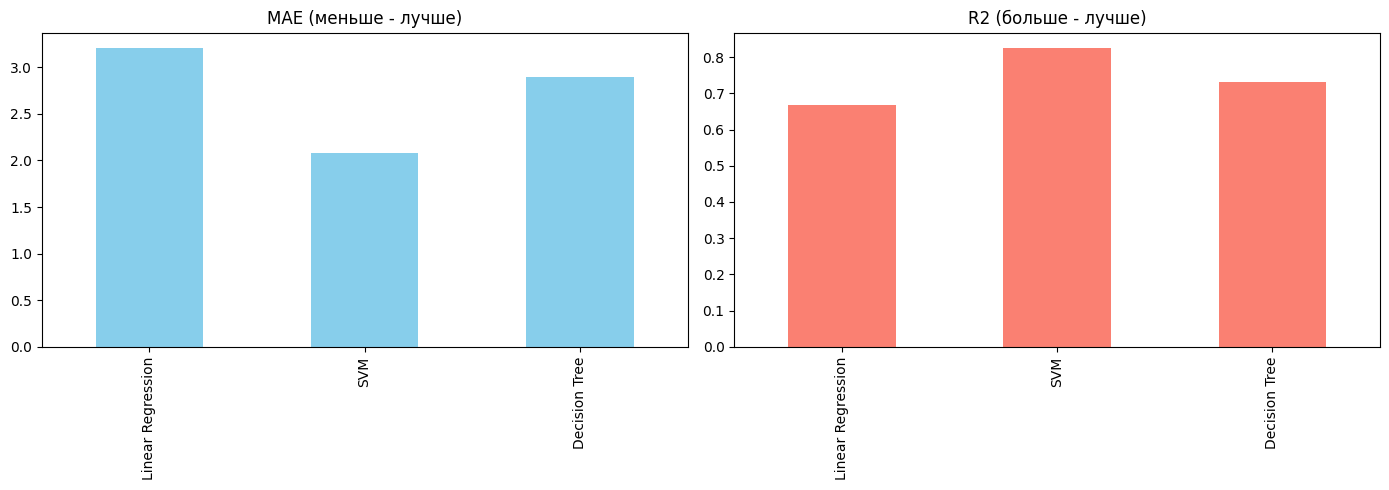

In [5]:
def evaluate(model, X_t, y_t, is_scaled=True):
    y_pred = model.predict(X_t)
    mae = mean_absolute_error(y_t, y_pred)
    r2 = r2_score(y_t, y_pred)
    return mae, r2

results = {
    'Linear Regression': evaluate(model_lr, X_test_scaled, y_test),
    'SVM': evaluate(model_svm, X_test_scaled, y_test),
    'Decision Tree': evaluate(model_dt, X_test, y_test)
}

res_df = pd.DataFrame(results, index=['MAE', 'R2']).T
print(res_df)

# Визуализация
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
res_df['MAE'].plot(kind='bar', ax=ax[0], color='skyblue', title='MAE (меньше - лучше)')
res_df['R2'].plot(kind='bar', ax=ax[1], color='salmon', title='R2 (больше - лучше)')
plt.tight_layout()
plt.show()

### 6. Важность признаков (Дерево решений)

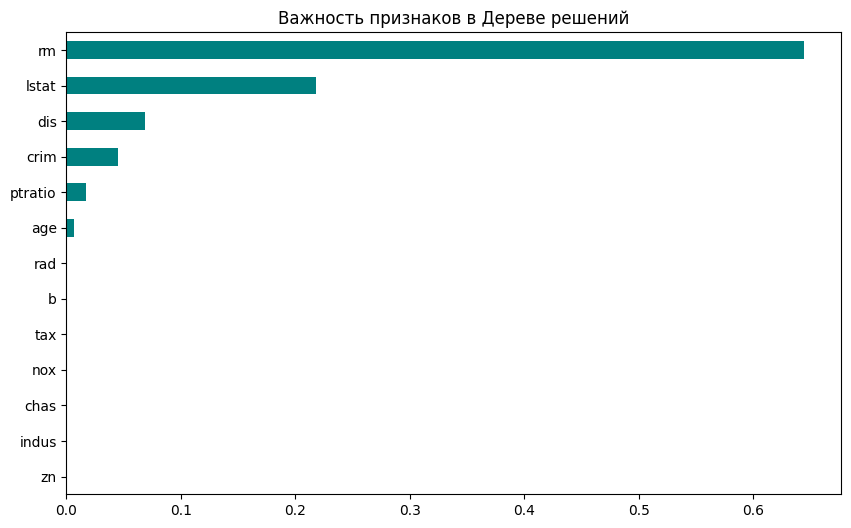

In [6]:
plt.figure(figsize=(10, 6))
feat_importance = pd.Series(model_dt.feature_importances_, index=X.columns)
feat_importance.sort_values().plot(kind='barh', color='teal')
plt.title('Важность признаков в Дереве решений')
plt.show()

### 7. Визуализация Дерева решений
Выведем графическую структуру и текстовые правила.

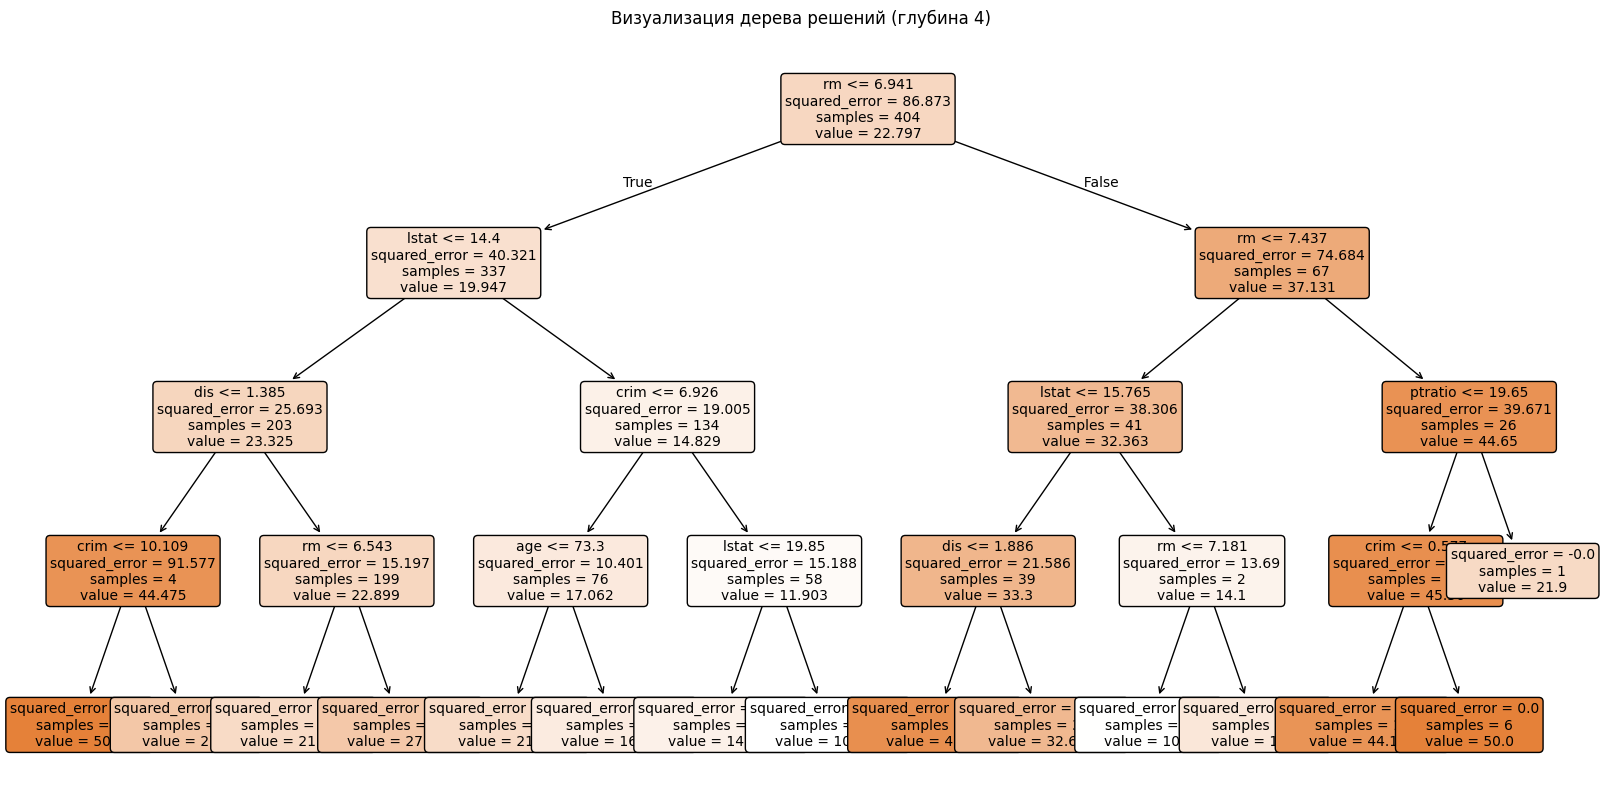

--- Текстовые правила дерева ---
|--- rm <= 6.94
|   |--- lstat <= 14.40
|   |   |--- dis <= 1.38
|   |   |   |--- crim <= 10.11
|   |   |   |   |--- value: [50.00]
|   |   |   |--- crim >  10.11
|   |   |   |   |--- value: [27.90]
|   |   |--- dis >  1.38
|   |   |   |--- rm <= 6.54
|   |   |   |   |--- value: [21.63]
|   |   |   |--- rm >  6.54
|   |   |   |   |--- value: [27.50]
|   |--- lstat >  14.40
|   |   |--- crim <= 6.93
|   |   |   |--- age <= 73.30
|   |   |   |   |--- value: [21.22]
|   |   |   |--- age >  73.30
|   |   |   |   |--- value: [16.43]
|   |   |--- crim >  6.93
|   |   |   |--- lstat <= 19.85
|   |   |   |   |--- value: [14.77]
|   |   |   |--- lstat >  19.85
|   |   |   |   |--- value: [10.28]
|--- rm >  6.94
|   |--- rm <= 7.44
|   |   |--- lstat <= 15.76
|   |   |   |--- dis <= 1.89
|   |   |   |   |--- value: [45.65]
|   |   |   |--- dis >  1.89
|   |   |   |   |--- value: [32.63]
|   |   |--- lstat >  15.76
|   |   |   |--- rm <= 7.18
|   |   |   |   |--- 

In [7]:
# Графическая визуализация
plt.figure(figsize=(20, 10))
plot_tree(model_dt, feature_names=X.columns, filled=True, rounded=True, fontsize=10)
plt.title('Визуализация дерева решений (глубина 4)')
plt.show()

# Текстовая визуализация
print("--- Текстовые правила дерева ---")
print(export_text(model_dt, feature_names=list(X.columns)))